# TP Module 1 — CNN pour la Computer Vision (classification de lésions cutanées)

**Formation avancée en Deep Learning avec PyTorch — Computer Vision & Séries temporelles**

*Bassem Ben Hamed — ENETCOM, Université de Sfax*

---

## Objectifs du TP

1. Comprendre pourquoi les **réseaux convolutifs (CNN)** sont mieux adaptés aux images que les MLP
2. Maîtriser les opérations clés : **convolution 2D, padding, stride, pooling, batchnorm**
3. Calculer la **forme des feature maps** et le **champ réceptif** d'une architecture
4. Construire un **module de data augmentation** robuste et le justifier théoriquement
5. Implémenter un **CNN from scratch** style VGG sur une tâche médicale multi-classe : **diagnostic de lésions cutanées** (7 classes)
6. Évaluer le modèle sur un dataset **déséquilibré** : courbes, matrice de confusion, précision/rappel/F1 par classe, visualisation des erreurs et des filtres

## Pré-requis

- Les TP 1 et 2 du Module 1
- `torch`, `torchvision`, `medmnist`, `matplotlib`, `numpy`, `Pillow`

## Dataset

**DermaMNIST** (collection [MedMNIST](https://medmnist.com/), dérivé de HAM10000) — 10 015 images dermatoscopiques **RGB** de lésions cutanées, réparties en **7 classes** diagnostiques (de la lésion bénigne au mélanome). Splits officiels : 7 007 (train) / 1 003 (val) / 2 005 (test). Le dataset est fortement **déséquilibré** (la classe *melanocytic nevi* domine), ce qui en fait un cas réaliste pour discuter des métriques au-delà de l'accuracy. Téléchargé automatiquement via la librairie `medmnist` dans `./data/`.

## Partie I — Théorie des CNN

### I.1 Pourquoi pas un MLP pour les images ?

Reprenons une image 224×224 RGB. Un MLP avec une seule couche cachée de 1024 neurones aurait :

$$
n_\text{params} = \underbrace{224 \cdot 224 \cdot 3}_{150\,528} \cdot 1024 + 1024 \approx 1.54 \cdot 10^8 \text{ paramètres}.
$$

Trois problèmes structurels :

1. **Explosion combinatoire** — 150 millions de poids juste pour la première couche.
2. **Pas d'invariance par translation** — une lésion dans le coin haut-gauche est une entrée *totalement différente* de la même lésion au centre.
3. **Pas de notion de voisinage** — l'aplatissement détruit la structure spatiale 2D ; deux pixels adjacents et deux pixels distants sont traités de la même façon.

Les **CNN** corrigent ces trois points par trois principes :
- **Connectivité locale** — chaque neurone ne voit qu'un voisinage spatial (le *receptive field*)
- **Partage de paramètres** — le même filtre est appliqué à toute l'image, ce qui détecte le même motif partout
- **Hiérarchie spatiale** — l'empilement de couches construit des features de plus en plus abstraits (bords → textures → parties → objets)

### I.2 La convolution 2D

Soient une image (à 1 canal) $X \in \mathbb{R}^{H \times W}$ et un **noyau** (kernel) $K \in \mathbb{R}^{k \times k}$. La convolution discrète (en pratique, *corrélation croisée* — PyTorch n'inverse pas le noyau) :

$$
(X * K)(i, j) = \sum_{m=0}^{k-1} \sum_{n=0}^{k-1} X(i+m,\, j+n) \cdot K(m, n).
$$

**Multi-canaux** — l'entrée a $C_\text{in}$ canaux, la sortie $C_\text{out}$. Le noyau devient un tenseur $K \in \mathbb{R}^{C_\text{out} \times C_\text{in} \times k \times k}$. Pour chaque canal de sortie $c$ :

$$
Y_{c, i, j} \;=\; b_c \;+\; \sum_{c'=1}^{C_\text{in}} \sum_{m=0}^{k-1} \sum_{n=0}^{k-1} K_{c, c', m, n} \cdot X_{c', i+m, j+n}.
$$

**Nombre de paramètres** d'une couche `nn.Conv2d(C_in, C_out, k)` :
$$
n_\text{params} = C_\text{out} \cdot C_\text{in} \cdot k^2 + C_\text{out}.
$$

**À comparer** : pour une image 224×224×3 et 64 features de sortie, un MLP utiliserait $\sim 10^7$ paramètres pour la première couche, contre seulement $64 \cdot 3 \cdot 3 \cdot 3 + 64 = 1\,792$ pour `Conv2d(3, 64, 3)`. **Facteur 5 000.**

### I.3 Stride, padding, taille de sortie

Deux hyperparamètres contrôlent la géométrie :

- **Padding** $p$ : nombre de pixels ajoutés autour de l'image (typiquement 0). Le *same padding* (avec $k$ impair et $p = (k-1)/2$) préserve la résolution.
- **Stride** $s$ : pas du déplacement du noyau. $s=2$ divise la résolution par 2 (sous-échantillonnage).

**Formule de la taille de sortie** :
$$
\boxed{\;
H_\text{out} = \left\lfloor \dfrac{H_\text{in} + 2p - k}{s} \right\rfloor + 1,
\qquad
W_\text{out} = \left\lfloor \dfrac{W_\text{in} + 2p - k}{s} \right\rfloor + 1.
\;}
$$

**Cas courants** :

| Configuration | Effet |
|---------------|-------|
| `k=3, p=1, s=1` | Préserve la résolution (3×3 le plus courant) |
| `k=3, p=1, s=2` | Divise par 2 (downsampling apprenable) |
| `k=1, p=0, s=1` | Mélange de canaux sans changement spatial |
| `k=7, p=3, s=2` | Première couche de ResNet (réduit fortement) |

**Exemple numérique** : entrée 224×224, `Conv2d(_, _, k=3, p=1, s=2)` → $\lfloor (224 + 2 - 3)/2 \rfloor + 1 = 112$.

### I.4 Pooling

Le **pooling** réduit la résolution sans paramètres apprenables. Pour un voisinage $\mathcal{N}_{i,j}$ de taille $k \times k$ :

$$
\text{MaxPool} : Y_{i,j} = \max_{(m,n) \in \mathcal{N}_{i,j}} X_{m,n},
\qquad
\text{AvgPool} : Y_{i,j} = \frac{1}{k^2} \sum_{(m,n) \in \mathcal{N}_{i,j}} X_{m,n}.
$$

- **MaxPool** : conserve les activations les plus fortes, robuste au bruit local, introduit une **invariance locale** par translation.
- **AvgPool** : lisse les activations, souvent utilisé en fin de réseau (Global Average Pooling) comme alternative au flatten.
- **AdaptiveAvgPool2d(output_size)** : adapte automatiquement le stride/kernel pour atteindre la taille demandée — pratique pour rendre le modèle indépendant de la taille d'entrée.

**Tendance actuelle** : remplacer MaxPool par des `Conv2d` avec stride=2 (downsampling apprenable, utilisé dans ResNet, EfficientNet).

### I.5 Champ réceptif (receptive field)

Le **champ réceptif** d'un neurone à la couche $\ell$ est la région de l'image d'entrée qui influence sa valeur. Il croît avec la profondeur :

$$
r_\ell = r_{\ell-1} + (k_\ell - 1) \prod_{i=1}^{\ell-1} s_i,
\qquad r_0 = 1.
$$

**Lecture** : ajouter une couche $3 \times 3$ après une convolution stride 2 augmente le champ réceptif de $2 \times 2 = 4$ pixels (en plus de l'existant).

**Exemple — VGG-like jusqu'au bloc 3** :

| Couche | $k$ | $s$ | $r$ |
|--------|-----|-----|-----|
| Conv1 | 3 | 1 | 3 |
| Conv2 | 3 | 1 | 5 |
| Pool  | 2 | 2 | 6 |
| Conv3 | 3 | 1 | 10 |
| Conv4 | 3 | 1 | 14 |
| Pool  | 2 | 2 | 16 |

Pour bien classer une lésion cutanée, on veut un champ réceptif qui couvre toute la lésion — sinon le réseau ne voit que des morceaux de texture.

### I.6 Bloc canonique : Conv – BatchNorm – ReLU – Pool

L'unité de base d'un CNN moderne est :

```
x → Conv2d(k=3, p=1) → BatchNorm2d → ReLU → [MaxPool2d(2,2)]
```

**BatchNorm 2D** normalise *par canal* sur tout le batch et tous les pixels :
$$
\mu_c = \frac{1}{NHW} \sum_{n,i,j} X_{n,c,i,j}, \quad
\sigma_c^2 = \frac{1}{NHW} \sum_{n,i,j} (X_{n,c,i,j} - \mu_c)^2,
$$
$$
\hat X_{n,c,i,j} = \frac{X_{n,c,i,j} - \mu_c}{\sqrt{\sigma_c^2 + \varepsilon}}, \quad
Y_{n,c,i,j} = \gamma_c \hat X_{n,c,i,j} + \beta_c.
$$

**Avantages** : stabilise les activations, accélère la convergence, autorise des learning rates plus grands, joue un rôle léger de régularisation.

**Mode** : `model.eval()` bascule BN sur les statistiques *running* (moyenne/variance mobiles) au lieu des stats du batch courant.

### I.7 Data augmentation — fondements

**Idée centrale** : le label d'une image est *invariant* sous certaines transformations. Une lésion cutanée reste la même lésion sous :

- **Symétries horizontale ET verticale** (une lésion n'a pas d'orientation canonique)
- **Rotation arbitraire** (l'angle de prise de vue dermatoscopique est arbitraire)
- **Recadrage** (random crop, zoom)
- **Variation photométrique légère** (luminosité, contraste)
- **Bruit léger, flou léger**

Augmenter le dataset avec ces transformations équivaut à **forcer le réseau à apprendre des features invariantes** à ces déformations. Formellement, on échantillonne $(x', y) = (T(x), y)$ avec $T \sim \mathcal{T}$ une loi sur les transformations admissibles. L'objectif devient :
$$
\mathcal{L}_\text{aug}(\theta) = \mathbb{E}_{(x,y) \sim \mathcal{D}} \; \mathbb{E}_{T \sim \mathcal{T}} \; \ell\bigl(f_\theta(T(x)), y\bigr).
$$

**Règles pratiques** :
- N'appliquer l'augmentation **qu'au train set**, jamais en validation ni en test.
- Choisir des transformations **cohérentes avec la tâche**. Pour la dermatoscopie, les **flips horizontaux et verticaux** ainsi que les **rotations libres** sont tous légitimes (pas d'orientation privilégiée) — contrairement à des photos d'objets du quotidien. En revanche, la **couleur est diagnostique** (la variégation chromatique est un critère de malignité du mélanome) : on garde donc un `ColorJitter` **modéré** pour ne pas détruire ce signal.
- Augmentations modernes : **MixUp** ($\tilde x = \lambda x_1 + (1-\lambda) x_2$, $\tilde y$ pareil), **CutMix** (collage de patches), **RandAugment** (séquence aléatoire).

**Effet attendu** : meilleure généralisation (réduction du gap train/val), modèle plus robuste aux variations de capture.

## Partie II — Préparation des données

### II.1 Imports et configuration

In [20]:
import os
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision.transforms import v2 as T
from medmnist import DermaMNIST, INFO

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch  : {torch.__version__}")
print(f"Device   : {device}")

ROOT     = Path("./data")
CKPT_DIR = Path("./checkpoints")
ROOT.mkdir(exist_ok=True); CKPT_DIR.mkdir(exist_ok=True)

IMG_SIZE = 128                # 128×128 — résolution native demandée à MedMNIST (fallback : upscaling depuis 28×28)
BATCH    = 64

info          = INFO["dermamnist"]
NUM_CLASSES   = len(info["label"])                                  # 7
CLASSES       = [info["label"][str(i)] for i in range(NUM_CLASSES)] # noms longs
CLASSES_SHORT = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]
print(f"Classes ({NUM_CLASSES}) :")
for i, name in enumerate(CLASSES):
    print(f"  {i} — {CLASSES_SHORT[i]:<6} {name}")

PyTorch  : 2.10.0
Device   : cpu
Classes (7) :
  0 — akiec  actinic keratoses and intraepithelial carcinoma
  1 — bcc    basal cell carcinoma
  2 — bkl    benign keratosis-like lesions
  3 — df     dermatofibroma
  4 — mel    melanoma
  5 — nv     melanocytic nevi
  6 — vasc   vascular lesions


### II.2 Téléchargement et inspection du dataset

On utilise `medmnist.DermaMNIST`, qui télécharge automatiquement le `.npz` correspondant dans `./data/`. On demande la résolution **128×128** (`size=128`) ; si la version de `medmnist` installée ne supporte pas ce paramètre, on retombe sur les images 28×28 d'origine, que le pipeline de transforms ré-échantillonnera.

**Note** : MedMNIST fournit des splits **train / val / test officiels** — on les utilise directement, sans `random_split` maison, pour garantir des comparaisons reproductibles avec la littérature.

In [ ]:
def make_derma(split, transform=None, target_transform=None):
    """Charge un split DermaMNIST en demandant size=IMG_SIZE (RGB natif),
    avec repli sur 28×28 si la version de medmnist ne connaît pas `size`."""
    kwargs = dict(split=split, root=ROOT, download=True,
                  transform=transform, target_transform=target_transform)
    try:
        return DermaMNIST(size=IMG_SIZE, **kwargs)
    except TypeError:
        return DermaMNIST(**kwargs)            # medmnist < 3.0 : images 28×28

# L'étiquette MedMNIST est un tableau (1,) -> on la ramène à un entier scalaire.
# /!\ Fonction NOMMÉE (pas un lambda) : un lambda n'est pas picklable, ce qui fait
# planter DataLoader(num_workers > 0) sous macOS/Windows (méthode « spawn ») avec
# « PicklingError: Can't pickle <lambda> ».
def squeeze_target(t):
    return int(np.asarray(t).reshape(-1)[0])

# Datasets bruts sans transformation, juste pour inspecter les images PIL
raw_train = make_derma("train")
raw_test  = make_derma("test")

print(f"Train : {len(raw_train)} images")
print(f"Val   : {len(make_derma('val'))} images")
print(f"Test  : {len(raw_test)} images")

img0, label0 = raw_train[0]
print(f"\nType image : {type(img0).__name__}, taille {img0.size}, mode {img0.mode}")
print(f"Label : {squeeze_target(label0)} ({CLASSES_SHORT[squeeze_target(label0)]})")

# Distribution des classes (train) — fortement déséquilibrée
labels = np.array([squeeze_target(raw_train[i][1]) for i in range(len(raw_train))])
print("\nDistribution train :")
for k in range(NUM_CLASSES):
    n = (labels == k).sum()
    print(f"  {CLASSES_SHORT[k]:<6} : {n:>5}  ({n/len(labels)*100:>5.1f}%)")

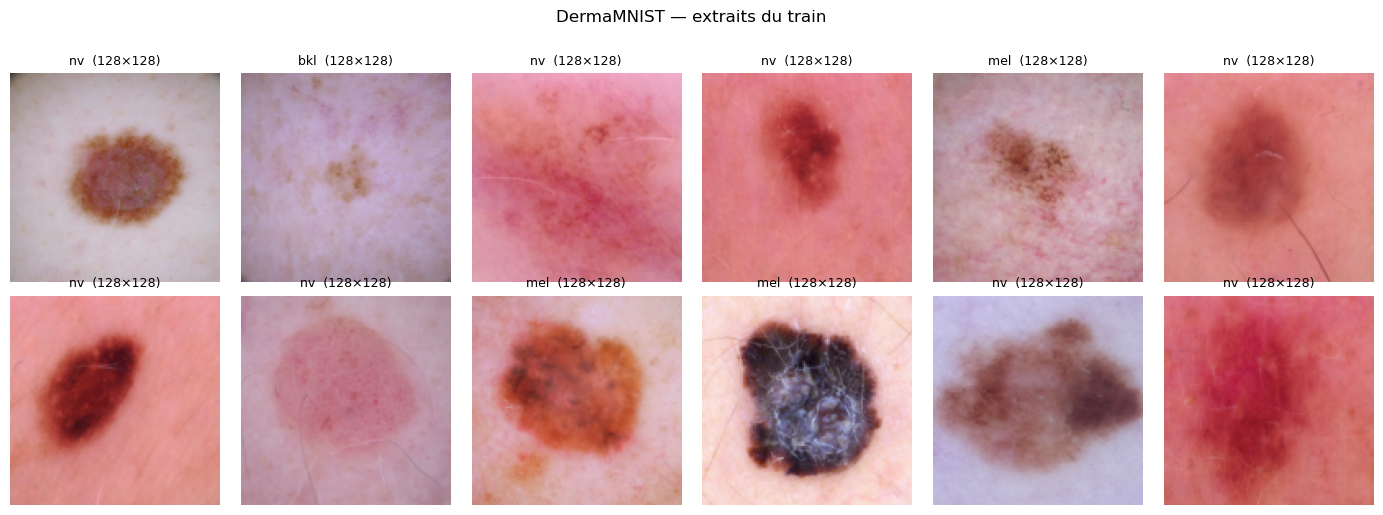

In [22]:
# Aperçu : 12 images du train
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
rng = np.random.default_rng(SEED)
idxs = rng.choice(len(raw_train), size=12, replace=False)
for ax, idx in zip(axes.flat, idxs):
    img, lab = raw_train[int(idx)]
    lab = squeeze_target(lab)
    ax.imshow(img)
    ax.set_title(f"{CLASSES_SHORT[lab]}  ({img.size[0]}×{img.size[1]})", fontsize=9)
    ax.axis("off")
plt.suptitle("DermaMNIST — extraits du train", y=1.02)
plt.tight_layout(); plt.show()

**Observation** : ici toutes les images partagent déjà la même taille (MedMNIST les fournit pré-redimensionnées). Le `Resize` / `RandomResizedCrop` reste néanmoins indispensable pour fixer la résolution d'entrée du réseau et, côté train, introduire de la variabilité spatiale.

## Partie III — Module de Data Augmentation

On encapsule les pipelines train/val dans une **classe dédiée** pour rendre le code propre et réutilisable. On utilise `torchvision.transforms.v2` (API moderne, plus rapide, supporte les Tensors et la composition).

### Pipeline d'entraînement

1. `RandomResizedCrop(size, scale=(0.7, 1.0))` — recadrage aléatoire + redimensionnement à `IMG_SIZE`
2. `RandomHorizontalFlip(p=0.5)` **et** `RandomVerticalFlip(p=0.5)` — une lésion n'a pas d'orientation privilégiée
3. `RandomRotation(degrees=180)` — rotation libre (angle dermatoscopique arbitraire)
4. `ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1)` — variations photométriques **modérées** (la couleur est diagnostique)
5. `ToImage()` + `ToDtype(float32, scale=True)` — conversion vers tenseur normalisé en $[0, 1]$
6. `Normalize(mean, std)` — standardisation ImageNet (utile pour transfer learning ultérieur)

### Pipeline de validation/test

1. `Resize(int(IMG_SIZE * 1.14))` + `CenterCrop(IMG_SIZE)` — recadrage déterministe au centre
2. Conversion tenseur + Normalize

Aucune randomisation côté val/test : on veut un score **reproductible**.

In [23]:
# Statistiques ImageNet — standard de facto, robuste pour transfer learning ultérieur
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

class DermaAugmenter:
    """Encapsule les pipelines de transformation train/val/test.

    Usage :
        aug = DermaAugmenter(img_size=128)
        train_set = make_derma("train", transform=aug.train, target_transform=squeeze_target)
        val_set   = make_derma("val",   transform=aug.eval,  target_transform=squeeze_target)
    """
    def __init__(self, img_size=128, mean=IMAGENET_MEAN, std=IMAGENET_STD,
                 hflip_p=0.5, vflip_p=0.5, rotation_deg=180,
                 brightness=0.2, contrast=0.2, saturation=0.1,
                 scale_range=(0.7, 1.0)):
        self.img_size = img_size
        self.mean, self.std = mean, std

        self.train = T.Compose([
            T.RandomResizedCrop(size=img_size, scale=scale_range, antialias=True),
            T.RandomHorizontalFlip(p=hflip_p),
            T.RandomVerticalFlip(p=vflip_p),
            T.RandomRotation(degrees=rotation_deg),
            T.ColorJitter(brightness=brightness, contrast=contrast, saturation=saturation),
            T.ToImage(),
            T.ToDtype(torch.float32, scale=True),
            T.Normalize(mean=mean, std=std),
        ])

        self.eval = T.Compose([
            T.Resize(int(img_size * 1.14), antialias=True),
            T.CenterCrop(img_size),
            T.ToImage(),
            T.ToDtype(torch.float32, scale=True),
            T.Normalize(mean=mean, std=std),
        ])

    def denormalize(self, tensor):
        """Inverse Normalize() pour la visualisation : ramène à [0, 1]."""
        mean = torch.tensor(self.mean).view(3, 1, 1)
        std  = torch.tensor(self.std).view(3, 1, 1)
        return (tensor.cpu() * std + mean).clamp(0, 1)

aug = DermaAugmenter(img_size=IMG_SIZE)
print("Pipeline train :")
print(aug.train)
print("\nPipeline eval :")
print(aug.eval)

Pipeline train :
Compose(
      RandomResizedCrop(size=(128, 128), scale=(0.7, 1.0), ratio=(0.75, 1.3333333333333333), interpolation=InterpolationMode.BILINEAR, antialias=True)
      RandomHorizontalFlip(p=0.5)
      RandomVerticalFlip(p=0.5)
      RandomRotation(degrees=[-180.0, 180.0], interpolation=InterpolationMode.NEAREST, expand=False, fill=0)
      ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.9, 1.1))
      ToImage()
      ToDtype(scale=True)
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
)

Pipeline eval :
Compose(
      Resize(size=[145], interpolation=InterpolationMode.BILINEAR, antialias=True)
      CenterCrop(size=(128, 128))
      ToImage()
      ToDtype(scale=True)
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
)


### III.1 Visualisation des augmentations

Pour vérifier visuellement le pipeline, on applique 8 fois l'augmentation **train** à la même image source. Chaque sortie est différente, ce qui montre la diversité injectée à chaque epoch.

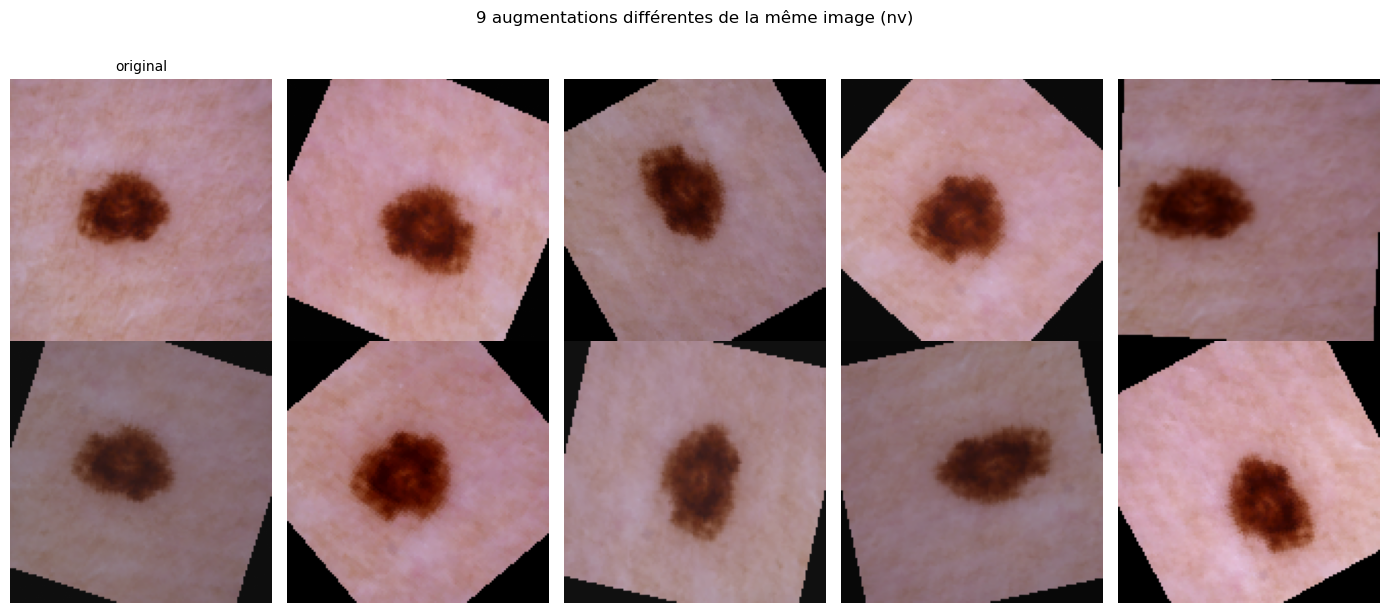

In [24]:
img_src, lab_src = raw_train[5]
lab_src = squeeze_target(lab_src)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
axes[0, 0].imshow(img_src); axes[0, 0].set_title("original", fontsize=10)
axes[0, 0].axis("off")
for ax in axes.flat[1:]:
    aug_t = aug.train(img_src)            # tenseur (C, H, W) normalisé
    img_show = aug.denormalize(aug_t).permute(1, 2, 0).numpy()
    ax.imshow(img_show)
    ax.axis("off")
plt.suptitle(f"9 augmentations différentes de la même image ({CLASSES_SHORT[lab_src]})", y=1.02)
plt.tight_layout(); plt.show()

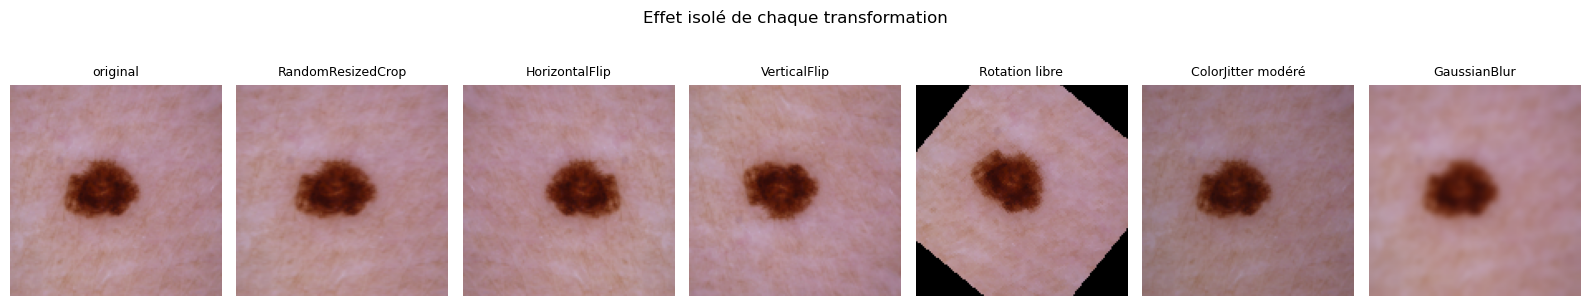

In [25]:
# Inspection isolée de chaque transformation
single_transforms = {
    "RandomResizedCrop":   T.RandomResizedCrop(IMG_SIZE, scale=(0.5, 1.0), antialias=True),
    "HorizontalFlip":      T.RandomHorizontalFlip(p=1.0),
    "VerticalFlip":        T.RandomVerticalFlip(p=1.0),
    "Rotation libre":      T.RandomRotation(degrees=180),
    "ColorJitter modéré":  T.ColorJitter(0.2, 0.2, 0.1),
    "GaussianBlur":        T.GaussianBlur(kernel_size=5, sigma=(2.0, 2.0)),
}

fig, axes = plt.subplots(1, 7, figsize=(16, 3))
axes[0].imshow(img_src); axes[0].set_title("original", fontsize=9); axes[0].axis("off")
for ax, (name, tfm) in zip(axes[1:], single_transforms.items()):
    out = tfm(img_src)
    ax.imshow(out)
    ax.set_title(name, fontsize=9); ax.axis("off")
plt.suptitle("Effet isolé de chaque transformation", y=1.05)
plt.tight_layout(); plt.show()

### III.2 Construction des Datasets et DataLoaders

On recharge les splits **officiels** de MedMNIST en attachant cette fois les transforms appropriés : augmentation aléatoire pour le train, transformation déterministe pour val/test.

In [26]:
train_set = make_derma("train", transform=aug.train, target_transform=squeeze_target)
val_set   = make_derma("val",   transform=aug.eval,  target_transform=squeeze_target)
test_set  = make_derma("test",  transform=aug.eval,  target_transform=squeeze_target)

PIN = device.type == "cuda"
train_loader = DataLoader(train_set, batch_size=BATCH, shuffle=True,  num_workers=0, pin_memory=PIN)
val_loader   = DataLoader(val_set,   batch_size=BATCH, shuffle=False, num_workers=0, pin_memory=PIN)
test_loader  = DataLoader(test_set,  batch_size=BATCH, shuffle=False, num_workers=0, pin_memory=PIN)

print(f"Train : {len(train_set):>5} | Val : {len(val_set):>5} | Test : {len(test_set):>5}")

x_batch, y_batch = next(iter(train_loader))
print(f"Batch : {x_batch.shape}  | labels : {y_batch.shape}  ({y_batch.dtype})")
print(f"Plage des pixels (post-Normalize) : [{x_batch.min():.2f}, {x_batch.max():.2f}]")

Train :  7007 | Val :  1003 | Test :  2005
Batch : torch.Size([64, 3, 128, 128])  | labels : torch.Size([64])  (torch.int64)
Plage des pixels (post-Normalize) : [-2.12, 2.64]


## Partie IV — CNN from scratch

On construit un **CNN de type VGG simplifié** :

```
Bloc 1 : Conv(3→32)  → BN → ReLU → Conv(32→32)  → BN → ReLU → MaxPool 2
Bloc 2 : Conv(32→64) → BN → ReLU → Conv(64→64)  → BN → ReLU → MaxPool 2
Bloc 3 : Conv(64→128)→ BN → ReLU → Conv(128→128)→ BN → ReLU → MaxPool 2
Bloc 4 : Conv(128→256)→BN → ReLU → Conv(256→256)→ BN → ReLU → AdaptiveAvgPool(1)
Classifieur : Flatten → Linear(256→128) → ReLU → Dropout(0.5) → Linear(128→7)
```

**Calcul des feature maps** (entrée 128×128) :

| Étape | Shape  | Notes |
|-------|--------|-------|
| Input | (3, 128, 128) | RGB normalisé |
| Bloc 1 + Pool | (32, 64, 64) | div par 2 |
| Bloc 2 + Pool | (64, 32, 32) | |
| Bloc 3 + Pool | (128, 16, 16) | |
| Bloc 4 + AdaptiveAvg | (256, 1, 1) | GAP |
| Flatten | (256,) | |
| Linear final | (7,) | logits (7 classes) |

In [ ]:
def conv_bn_relu(in_c, out_c, k=3, p=1):
    return nn.Sequential(
        nn.Conv2d(in_c, out_c, kernel_size=k, padding=p, bias=False),
        nn.BatchNorm2d(out_c),
        nn.ReLU(inplace=True),
    )

class SmallVGG(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, dropout=0.5):
        super().__init__()
        self.features = nn.Sequential(
            # Bloc 1
            conv_bn_relu(3, 32),  conv_bn_relu(32, 32),  nn.MaxPool2d(2),
            # Bloc 2
            conv_bn_relu(32, 64), conv_bn_relu(64, 64),  nn.MaxPool2d(2),
            # Bloc 3
            conv_bn_relu(64, 128), conv_bn_relu(128, 128), nn.MaxPool2d(2),
            # Bloc 4
            conv_bn_relu(128, 256), conv_bn_relu(256, 256),
            nn.AdaptiveAvgPool2d(1),    # (N, 256, 1, 1)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),               # (N, 256)
            nn.Linear(256, 128), nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

    @staticmethod
    def count_params(m):
        return sum(p.numel() for p in m.parameters() if p.requires_grad)

model = SmallVGG().to(device)
print(f"Paramètres apprenables : {SmallVGG.count_params(model):,}")

# Sanity check des dimensions sur un batch
model.eval()
with torch.no_grad():
    out = model(x_batch.to(device))
print(f"\nForme de sortie : {out.shape}   (attendu : ({BATCH}, {NUM_CLASSES}))")

Paramètres apprenables : 1,207,015

Forme de sortie : torch.Size([64, 7])   (attendu : (64, 7))


In [28]:
# Inspection couche par couche : forme des feature maps
def trace_shapes(model, input_shape=(1, 3, IMG_SIZE, IMG_SIZE)):
    x = torch.zeros(input_shape, device=device)
    print(f"{'layer':<30} {'shape sortie':>22}")
    print("-" * 56)
    for i, layer in enumerate(model.features):
        x = layer(x)
        name = layer.__class__.__name__
        if name == "Sequential":
            name = f"ConvBNReLU#{i}"
        print(f"{name:<30} {str(tuple(x.shape)):>22}")
    x = model.classifier(x)
    print(f"{'Classifier':<30} {str(tuple(x.shape)):>22}")

trace_shapes(model)

layer                                    shape sortie
--------------------------------------------------------
ConvBNReLU#0                        (1, 32, 128, 128)
ConvBNReLU#1                        (1, 32, 128, 128)
MaxPool2d                             (1, 32, 64, 64)
ConvBNReLU#3                          (1, 64, 64, 64)
ConvBNReLU#4                          (1, 64, 64, 64)
MaxPool2d                             (1, 64, 32, 32)
ConvBNReLU#6                         (1, 128, 32, 32)
ConvBNReLU#7                         (1, 128, 32, 32)
MaxPool2d                            (1, 128, 16, 16)
ConvBNReLU#9                         (1, 256, 16, 16)
ConvBNReLU#10                        (1, 256, 16, 16)
AdaptiveAvgPool2d                      (1, 256, 1, 1)
Classifier                                     (1, 7)


## Partie V — Entraînement

**Configuration** :
- Loss : `CrossEntropyLoss` **pondérée par l'inverse de la fréquence des classes** — indispensable sur DermaMNIST, fortement déséquilibré, pour éviter que le modèle ne prédise systématiquement la classe majoritaire *nv*
- Optimiseur : Adam, `lr=1e-3`, `weight_decay=1e-4`
- Scheduler : `CosineAnnealingLR` sur 12 epochs
- Early stopping implicite : on garde le meilleur état val (sur l'accuracy)

In [29]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    tot_loss, tot_correct, tot = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        optimizer.zero_grad()
        logits = model(x)
        loss   = criterion(logits, y)
        loss.backward()
        optimizer.step()
        tot_loss    += loss.item() * x.size(0)
        tot_correct += (logits.argmax(1) == y).sum().item()
        tot         += x.size(0)
    return tot_loss / tot, tot_correct / tot

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    tot_loss, tot_correct, tot = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        logits = model(x)
        loss   = criterion(logits, y)
        tot_loss    += loss.item() * x.size(0)
        tot_correct += (logits.argmax(1) == y).sum().item()
        tot         += x.size(0)
    return tot_loss / tot, tot_correct / tot

In [30]:
EPOCHS = 12

# Poids de classes = inverse de la fréquence (normalisé), pour compenser le déséquilibre
class_counts  = np.bincount(labels, minlength=NUM_CLASSES).astype(np.float32)
class_weights = class_counts.sum() / (NUM_CLASSES * class_counts)
class_weights = torch.tensor(class_weights, dtype=torch.float32, device=device)
print("Poids de classes :", {CLASSES_SHORT[i]: round(float(w), 2) for i, w in enumerate(class_weights)})

torch.manual_seed(SEED)
model     = SmallVGG().to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "lr": []}
best_val_acc, best_state = 0.0, None
t0 = time.time()

for epoch in range(1, EPOCHS + 1):
    tl, ta = train_one_epoch(model, train_loader, criterion, optimizer, device)
    vl, va = evaluate(model, val_loader, criterion, device)
    history["train_loss"].append(tl); history["train_acc"].append(ta)
    history["val_loss"].append(vl);   history["val_acc"].append(va)
    history["lr"].append(optimizer.param_groups[0]["lr"])

    if va > best_val_acc:
        best_val_acc = va
        best_state   = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    scheduler.step()
    print(f"epoch {epoch:>2}/{EPOCHS} | lr={history['lr'][-1]:.5f} | "
          f"train loss={tl:.4f} acc={ta:.4f} | val loss={vl:.4f} acc={va:.4f}")

print(f"\nDurée totale : {time.time()-t0:.0f}s | best val acc : {best_val_acc:.4f}")

model.load_state_dict(best_state)
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"Test : loss = {test_loss:.4f} | accuracy = {test_acc:.4f}")

Poids de classes : {'akiec': 4.39, 'bcc': 2.79, 'bkl': 1.3, 'df': 12.51, 'mel': 1.28, 'nv': 0.21, 'vasc': 10.11}
epoch  1/12 | lr=0.00100 | train loss=1.8192 acc=0.3310 | val loss=1.6571 acc=0.4656
epoch  2/12 | lr=0.00098 | train loss=1.6760 acc=0.4069 | val loss=1.5431 acc=0.3958
epoch  3/12 | lr=0.00093 | train loss=1.6055 acc=0.4179 | val loss=1.5211 acc=0.4497
epoch  4/12 | lr=0.00085 | train loss=1.5488 acc=0.4386 | val loss=1.5578 acc=0.4566
epoch  5/12 | lr=0.00075 | train loss=1.5363 acc=0.4340 | val loss=1.5173 acc=0.4317
epoch  6/12 | lr=0.00063 | train loss=1.5107 acc=0.4446 | val loss=1.4439 acc=0.4606
epoch  7/12 | lr=0.00050 | train loss=1.5232 acc=0.4287 | val loss=1.4252 acc=0.4666
epoch  8/12 | lr=0.00037 | train loss=1.5003 acc=0.4517 | val loss=1.3932 acc=0.4855
epoch  9/12 | lr=0.00025 | train loss=1.4389 acc=0.4672 | val loss=1.4017 acc=0.4905
epoch 10/12 | lr=0.00015 | train loss=1.4206 acc=0.4727 | val loss=1.3908 acc=0.4975
epoch 11/12 | lr=0.00007 | train loss

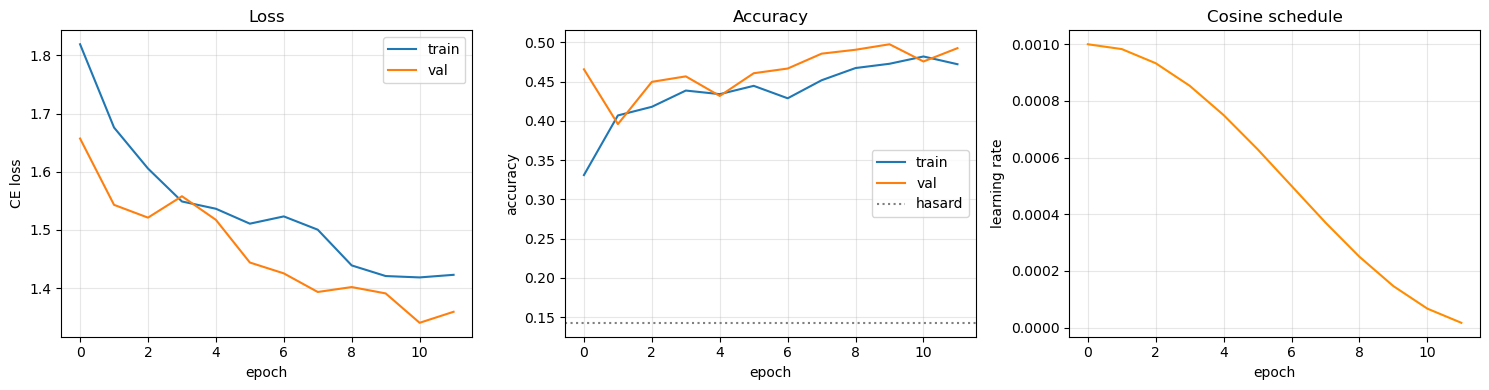

In [31]:
# Courbes d'apprentissage
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"],   label="val")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("CE loss")
axes[0].legend(); axes[0].grid(alpha=0.3); axes[0].set_title("Loss")

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"],   label="val")
axes[1].axhline(1/NUM_CLASSES, color="gray", linestyle=":", label="hasard")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy")
axes[1].legend(); axes[1].grid(alpha=0.3); axes[1].set_title("Accuracy")

axes[2].plot(history["lr"], color="darkorange")
axes[2].set_xlabel("epoch"); axes[2].set_ylabel("learning rate")
axes[2].grid(alpha=0.3); axes[2].set_title("Cosine schedule")
plt.tight_layout(); plt.show()

## Partie VI — Évaluation détaillée

### VI.1 Matrice de confusion et prédictions

Classe      Prec     Rec      F1   Support
-----------------------------------------
akiec      0.187   0.470   0.267        66
bcc        0.262   0.485   0.340       103
bkl        0.290   0.291   0.290       220
df         0.077   0.304   0.123        23
mel        0.261   0.623   0.368       223
nv         0.968   0.535   0.689      1341
vasc       0.371   0.793   0.505        29
-----------------------------------------
macro      0.345   0.500   0.369      2005


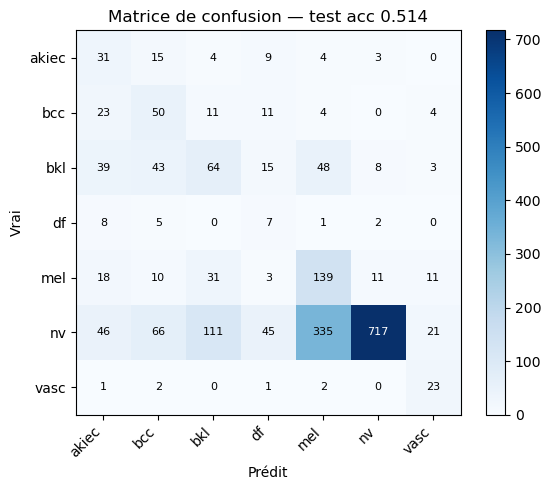

In [32]:
@torch.no_grad()
def collect_predictions(model, loader, device):
    model.eval()
    y_true, y_pred, y_probs = [], [], []
    for x, y in loader:
        x = x.to(device)
        logits = model(x)
        probs  = F.softmax(logits, dim=1)
        y_true.append(y.numpy())
        y_pred.append(logits.argmax(1).cpu().numpy())
        y_probs.append(probs.cpu().numpy())
    return (np.concatenate(y_true),
            np.concatenate(y_pred),
            np.concatenate(y_probs))

y_true, y_pred, y_probs = collect_predictions(model, test_loader, device)

K = NUM_CLASSES
cm = np.zeros((K, K), dtype=int)
for t, p in zip(y_true, y_pred): cm[t, p] += 1

precision = cm.diagonal() / cm.sum(axis=0).clip(min=1)
recall    = cm.diagonal() / cm.sum(axis=1).clip(min=1)
f1        = 2 * precision * recall / (precision + recall).clip(min=1e-12)

print(f"{'Classe':<8} {'Prec':>7} {'Rec':>7} {'F1':>7} {'Support':>9}")
print("-" * 41)
for c, p, r, fs, s in zip(CLASSES_SHORT, precision, recall, f1, cm.sum(axis=1)):
    print(f"{c:<8} {p:>7.3f} {r:>7.3f} {fs:>7.3f} {s:>9}")
print("-" * 41)
print(f"{'macro':<8} {precision.mean():>7.3f} {recall.mean():>7.3f} {f1.mean():>7.3f} {cm.sum():>9}")

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(K)); ax.set_yticks(range(K))
ax.set_xticklabels(CLASSES_SHORT, rotation=45, ha="right"); ax.set_yticklabels(CLASSES_SHORT)
ax.set_xlabel("Prédit"); ax.set_ylabel("Vrai")
ax.set_title(f"Matrice de confusion — test acc {test_acc:.3f}")
for i in range(K):
    for j in range(K):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=8,
                color="white" if cm[i, j] > cm.max()/2 else "black")
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

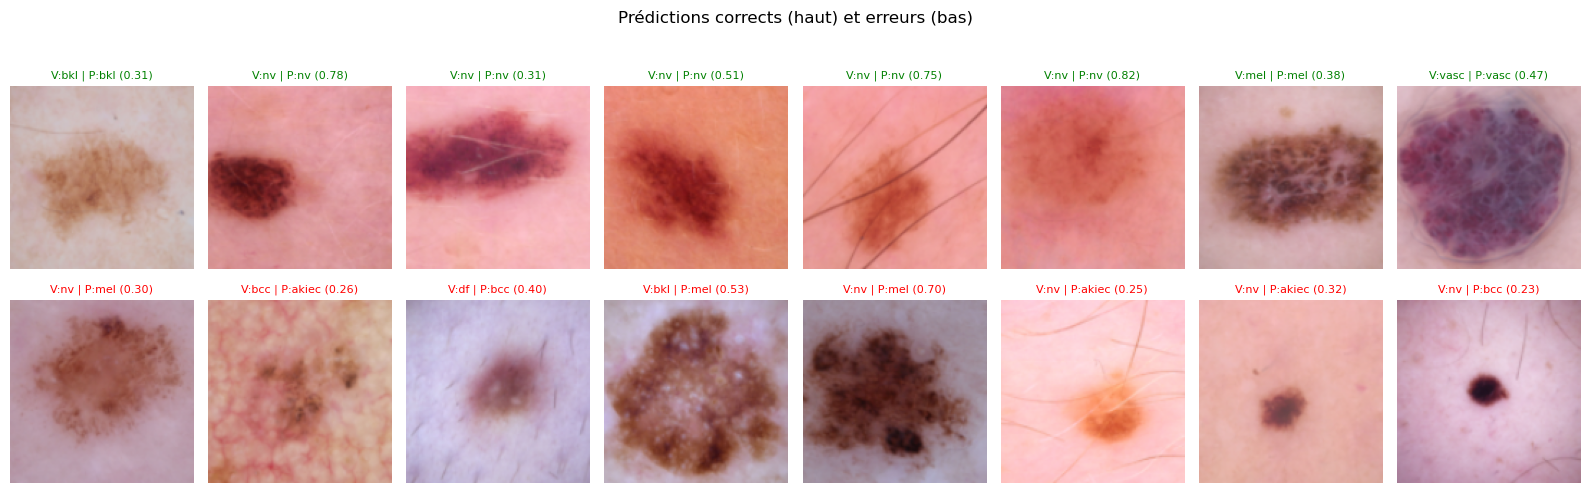

In [33]:
# Visualisation des prédictions : 8 corrects + 8 erreurs
correct_idx = np.where(y_true == y_pred)[0]
wrong_idx   = np.where(y_true != y_pred)[0]
rng = np.random.default_rng(SEED)
sel_ok  = rng.choice(correct_idx, size=min(8, len(correct_idx)), replace=False)
sel_err = rng.choice(wrong_idx,   size=min(8, len(wrong_idx)),   replace=False)

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
for row, (idxs, header) in enumerate([(sel_ok, "Corrects"), (sel_err, "Erreurs")]):
    for col, idx in enumerate(idxs):
        img, lab = test_set[int(idx)]
        axes[row, col].imshow(aug.denormalize(img).permute(1, 2, 0).numpy())
        conf = y_probs[idx, y_pred[idx]]
        color = "green" if y_true[idx] == y_pred[idx] else "red"
        axes[row, col].set_title(
            f"V:{CLASSES_SHORT[lab]} | P:{CLASSES_SHORT[y_pred[idx]]} ({conf:.2f})",
            fontsize=8, color=color)
        axes[row, col].axis("off")
    axes[row, 0].set_ylabel(header, fontsize=11)
plt.suptitle("Prédictions corrects (haut) et erreurs (bas)", y=1.02)
plt.tight_layout(); plt.show()

### VI.2 Visualisation des filtres de la première couche

Les **noyaux 3×3 de la première convolution** sont directement interprétables (on voit ce que chaque filtre détecte). Avec 32 filtres `(3, 3, 3)`, on peut les afficher comme des petites images RGB.

Forme des filtres : (32, 3, 3, 3)


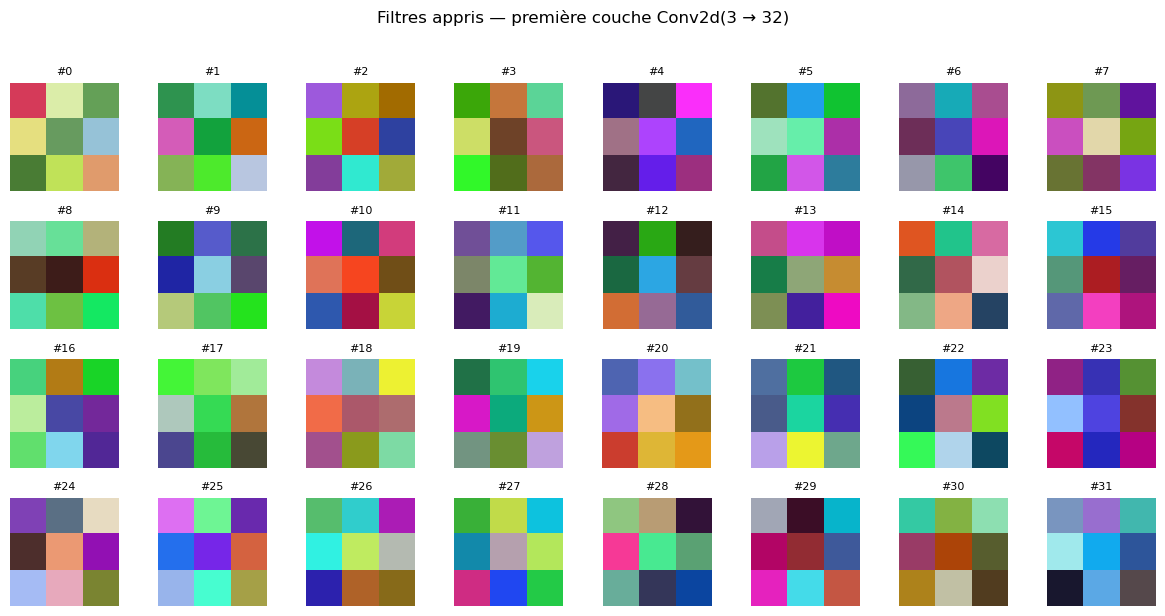

In [34]:
first_conv = model.features[0][0]    # nn.Conv2d à l'entrée
filters = first_conv.weight.detach().cpu().numpy()   # (32, 3, 3, 3)
print(f"Forme des filtres : {filters.shape}")

# Normalisation [0, 1] pour l'affichage
f_min, f_max = filters.min(), filters.max()
filters_vis = (filters - f_min) / (f_max - f_min)

fig, axes = plt.subplots(4, 8, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    if i < filters_vis.shape[0]:
        ax.imshow(filters_vis[i].transpose(1, 2, 0))
        ax.set_title(f"#{i}", fontsize=8)
    ax.axis("off")
plt.suptitle("Filtres appris — première couche Conv2d(3 → 32)", y=1.02)
plt.tight_layout(); plt.show()

### VI.3 Visualisation des feature maps

On extrait l'activation après le **premier bloc convolutif** pour une image de test, puis on affiche les 16 premières feature maps. On voit chaque filtre "s'allumer" sur des zones précises de l'image (bords, textures, contraste).

Forme des feature maps : torch.Size([32, 64, 64])


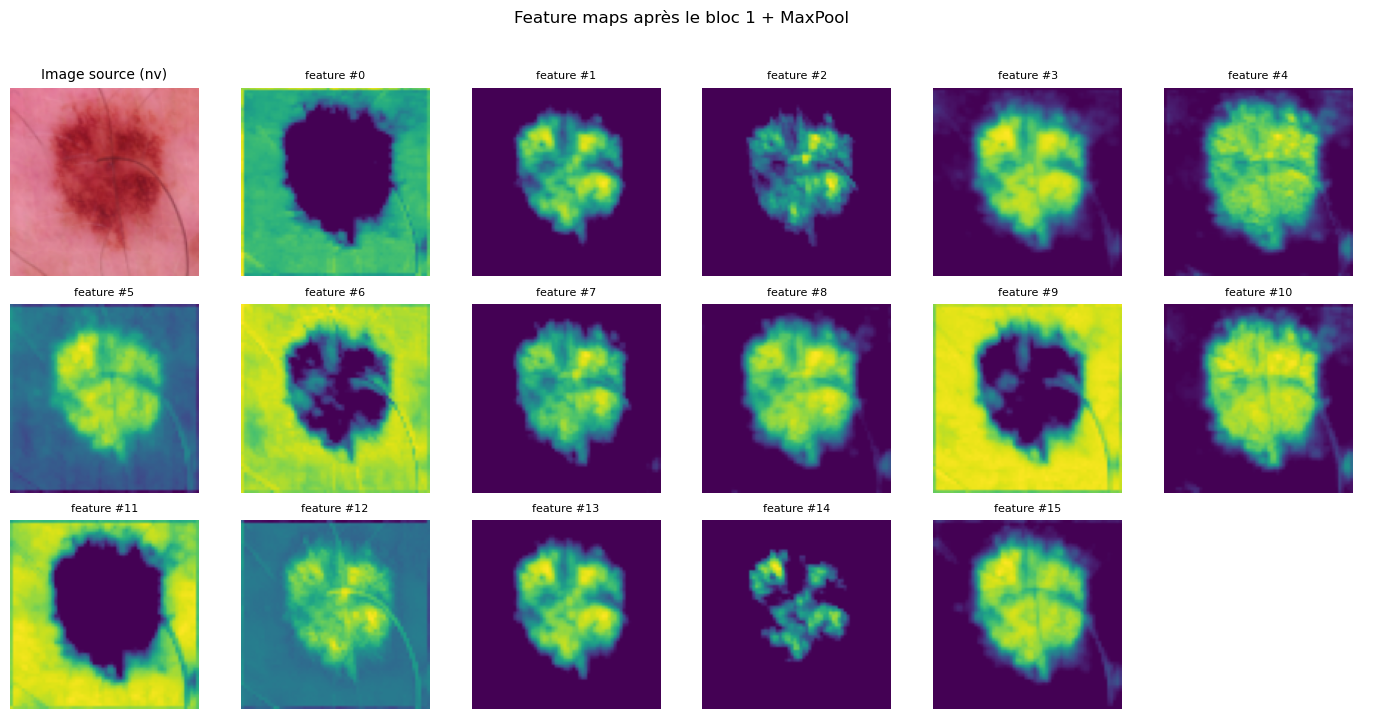

In [35]:
# Hook pour capturer la sortie d'une couche intermédiaire
activations = {}
def hook(name):
    def fn(module, inp, out): activations[name] = out.detach()
    return fn

handle = model.features[2].register_forward_hook(hook("block1"))  # après le premier MaxPool

img_t, lab_t = test_set[5]
with torch.no_grad():
    _ = model(img_t.unsqueeze(0).to(device))
handle.remove()

fmaps = activations["block1"][0].cpu()    # (32, 64, 64)
print(f"Forme des feature maps : {fmaps.shape}")

fig, axes = plt.subplots(3, 6, figsize=(14, 7))
axes[0, 0].imshow(aug.denormalize(img_t).permute(1, 2, 0).numpy())
axes[0, 0].set_title(f"Image source ({CLASSES_SHORT[lab_t]})", fontsize=10)
axes[0, 0].axis("off")
for i, ax in enumerate(axes.flat[1:]):
    if i < 16:
        ax.imshow(fmaps[i].numpy(), cmap="viridis")
        ax.set_title(f"feature #{i}", fontsize=8)
    ax.axis("off")
plt.suptitle("Feature maps après le bloc 1 + MaxPool", y=1.02)
plt.tight_layout(); plt.show()

## Partie VII — Étude d'ablation : avec/sans data augmentation

Pour quantifier l'apport du module de data augmentation, on ré-entraîne le **même modèle** sans augmentation (juste resize + center crop + normalize) et on compare.

In [36]:
# Pipeline minimal sans augmentation
no_aug_pipeline = T.Compose([
    T.Resize(int(IMG_SIZE * 1.14), antialias=True),
    T.CenterCrop(IMG_SIZE),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

train_set_no_aug = make_derma("train", transform=no_aug_pipeline, target_transform=squeeze_target)
train_loader_no_aug = DataLoader(train_set_no_aug, batch_size=BATCH, shuffle=True,
                                 num_workers=0, pin_memory=PIN)

EPOCHS_ABL = 8
torch.manual_seed(SEED)
model_no_aug = SmallVGG().to(device)
opt_no_aug   = torch.optim.Adam(model_no_aug.parameters(), lr=1e-3, weight_decay=1e-4)
sch_no_aug   = torch.optim.lr_scheduler.CosineAnnealingLR(opt_no_aug, T_max=EPOCHS_ABL)

hist_no_aug = {"train_acc": [], "val_acc": []}
for epoch in range(1, EPOCHS_ABL + 1):
    _, ta = train_one_epoch(model_no_aug, train_loader_no_aug, criterion, opt_no_aug, device)
    _, va = evaluate(model_no_aug, val_loader, criterion, device)
    hist_no_aug["train_acc"].append(ta); hist_no_aug["val_acc"].append(va)
    sch_no_aug.step()
    print(f"[NO AUG] epoch {epoch}/{EPOCHS_ABL} | train acc={ta:.4f} | val acc={va:.4f}")

[NO AUG] epoch 1/8 | train acc=0.3584 | val acc=0.4118
[NO AUG] epoch 2/8 | train acc=0.4448 | val acc=0.4885
[NO AUG] epoch 3/8 | train acc=0.4591 | val acc=0.2762
[NO AUG] epoch 4/8 | train acc=0.4745 | val acc=0.4556
[NO AUG] epoch 5/8 | train acc=0.4775 | val acc=0.4237
[NO AUG] epoch 6/8 | train acc=0.5055 | val acc=0.5015
[NO AUG] epoch 7/8 | train acc=0.5014 | val acc=0.5155
[NO AUG] epoch 8/8 | train acc=0.5152 | val acc=0.5174


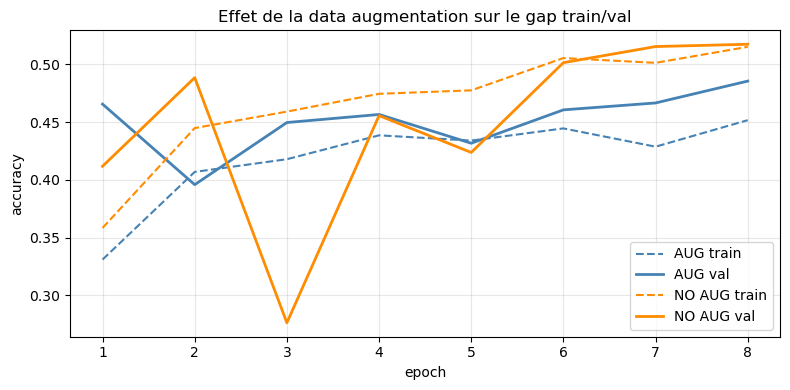


Gap final train-val :
  Avec augmentation : -0.0339
  Sans augmentation : -0.0022


In [37]:
# Comparaison train/val pour les 8 premières epochs
fig, ax = plt.subplots(figsize=(8, 4))
ep = range(1, EPOCHS_ABL + 1)
ax.plot(ep, history["train_acc"][:EPOCHS_ABL], "--", color="steelblue", label="AUG train")
ax.plot(ep, history["val_acc"][:EPOCHS_ABL],         color="steelblue", label="AUG val", linewidth=2)
ax.plot(ep, hist_no_aug["train_acc"],          "--", color="darkorange", label="NO AUG train")
ax.plot(ep, hist_no_aug["val_acc"],                   color="darkorange", label="NO AUG val", linewidth=2)
ax.set_xlabel("epoch"); ax.set_ylabel("accuracy")
ax.legend(); ax.grid(alpha=0.3)
ax.set_title("Effet de la data augmentation sur le gap train/val")
plt.tight_layout(); plt.show()

print(f"\nGap final train-val :")
print(f"  Avec augmentation : {history['train_acc'][EPOCHS_ABL-1] - history['val_acc'][EPOCHS_ABL-1]:.4f}")
print(f"  Sans augmentation : {hist_no_aug['train_acc'][-1] - hist_no_aug['val_acc'][-1]:.4f}")

## Partie VIII — Sauvegarde du modèle

In [38]:
ckpt_path = CKPT_DIR / "smallvgg_dermamnist_best.pt"
torch.save({
    "model_state_dict":   best_state,
    "arch":               "SmallVGG",
    "img_size":           IMG_SIZE,
    "normalize_mean":     IMAGENET_MEAN,
    "normalize_std":      IMAGENET_STD,
    "classes":            CLASSES,
    "classes_short":      CLASSES_SHORT,
    "best_val_acc":       best_val_acc,
    "test_acc":           test_acc,
    "n_params":           SmallVGG.count_params(model),
}, ckpt_path)
print(f"Modèle sauvegardé : {ckpt_path}")
print(f"Taille : {ckpt_path.stat().st_size / 1024 / 1024:.2f} MB")

Modèle sauvegardé : checkpoints/smallvgg_dermamnist_best.pt
Taille : 4.63 MB


## Partie IX — Exercices d'application

### Exercice 1 — Calcul de la taille de sortie
Une image $224 \times 224$ traverse :
- `Conv2d(3, 64, kernel_size=7, stride=2, padding=3)`
- `MaxPool2d(kernel_size=3, stride=2, padding=1)`
- `Conv2d(64, 128, kernel_size=3, stride=1, padding=1)`
- `Conv2d(128, 128, kernel_size=3, stride=2, padding=1)`

Calculez à la main la forme de la feature map après chaque couche. Vérifiez en l'instanciant en PyTorch.

### Exercice 2 — Comparaison MaxPool vs Strided Conv
Remplacez tous les `nn.MaxPool2d(2)` de `SmallVGG` par une `nn.Conv2d(c, c, 3, stride=2, padding=1)`. Comparez :
- nombre de paramètres total ;
- val accuracy après 10 epochs.

### Exercice 3 — Skip connection ResNet-style
Définissez un `BasicBlock` ResNet :
```python
class BasicBlock(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.conv1 = nn.Conv2d(c, c, 3, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(c)
        self.conv2 = nn.Conv2d(c, c, 3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(c)
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return F.relu(out + x)
```
Insérez 2 blocs ResNet par étage dans `SmallVGG`. Mesurez l'effet sur la convergence.

### Exercice 4 — MixUp
Implémentez MixUp dans la boucle d'entraînement :
$$
\tilde x = \lambda x_i + (1-\lambda) x_j, \quad
\tilde y = \lambda y_i + (1-\lambda) y_j, \quad
\lambda \sim \text{Beta}(\alpha, \alpha),\;\alpha=0.2.
$$
Adaptez la loss : `loss = λ * CE(out, y_i) + (1-λ) * CE(out, y_j)`. Mesurez le gain.

### Exercice 5 — Gérer le déséquilibre des classes
DermaMNIST est fortement déséquilibré (*nv* domine, *df* et *vasc* sont rares). Comparez trois stratégies sur la **macro-F1** (pas seulement l'accuracy) :
- `CrossEntropyLoss` **sans** pondération ;
- `CrossEntropyLoss` **pondérée** par l'inverse des fréquences (comme dans ce TP) ;
- **oversampling** des classes minoritaires via `torch.utils.data.WeightedRandomSampler` dans le `DataLoader`.

Lesquelles améliorent le rappel des classes rares sans trop dégrader l'accuracy globale ?

### Exercice 6 — Effet du champ réceptif
Modifiez `SmallVGG` pour avoir un seul Conv 7×7 stride 1 padding 3 en remplacement des deux Conv 3×3 du bloc 1. À paramètres comparables, quel est l'effet sur la val accuracy ? Discutez le compromis champ réceptif vs profondeur.

---

## Synthèse — API PyTorch CNN

| Concept | API PyTorch |
|---------|-------------|
| Convolution 2D | `nn.Conv2d(in_c, out_c, k, stride, padding)` |
| Convolution transposée (upsampling) | `nn.ConvTranspose2d(...)` |
| Pooling | `nn.MaxPool2d(k, s)`, `nn.AvgPool2d`, `nn.AdaptiveAvgPool2d(out_size)` |
| Normalisation | `nn.BatchNorm2d(num_features)`, `nn.GroupNorm(num_groups, ...)` |
| Aplatissement | `nn.Flatten()` |
| Augmentations modernes | `torchvision.transforms.v2` (RandomResizedCrop, ColorJitter, MixUp...) |
| Datasets vision / médicaux | `torchvision.datasets.{ImageFolder, CIFAR10, ...}`, `medmnist.{DermaMNIST, PneumoniaMNIST, ...}` |
| Hooks | `module.register_forward_hook(fn)`, `register_backward_hook(fn)` |
| Modèles pré-entraînés | `torchvision.models.resnet50(weights=ResNet50_Weights.DEFAULT)` |

---

**Prochain TP** (Module 2) : *Transfer Learning sur DermaMNIST — Fine-tuning de ResNet (ResNet18)*.